# Attractor Landscape Random Walk Simulation

A stochastic particle walk over a continuous 2D energy landscape composed of Gaussian attractor basins.  
Implements overdamped **Langevin dynamics**: deterministic gradient force + Gaussian noise.

**Tracked quantities**
- Time spent in each basin (dwell time)
- Euclidean path length travelled between consecutive basin visits

**Key parameters**

| Parameter | Description |
|-----------|-------------|
| `depth` | Well depth — deeper = stronger restoring force |
| `width` | Gaussian σ — controls catchment area |
| `noise_sigma` | Thermal noise amplitude (kT analogue) |
| `force_scale` | dt/γ — scales raw gradient force; makes depth physically meaningful |
| `n_steps` | Simulation length |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Light theme defaults
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor":   "#f8f8f8",
    "axes.edgecolor":   "#cccccc",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#333333",
    "ytick.color":      "#333333",
    "text.color":       "#333333",
    "grid.color":       "#dddddd",
    "figure.dpi":       120,
})
DARK = "#ffffff"; MID = "#f8f8f8"; TEXT = "#333333"
print("Imports OK")

Imports OK


## 1 · Data Structures

In [4]:
@dataclass
class Basin:
    """A single Gaussian attractor basin."""
    x: float       # centre x
    y: float       # centre y
    depth: float   # well depth (positive = attracts)
    width: float   # σ of the Gaussian
    label: str = ""

    def energy(self, px: float, py: float) -> float:
        r2 = (px - self.x)**2 + (py - self.y)**2
        return -self.depth * np.exp(-r2 / (2 * self.width**2))


@dataclass
class LandscapeConfig:
    """
    Full specification of the attractor landscape and walk dynamics.

    force_scale  : dt/gamma — scales raw gradient force.
                   Steeper wells → proportionally stronger restoring forces.
                   This is what makes depth a meaningful variable.
    noise_sigma  : Gaussian noise std at each step (thermal/kT analogue).
    """
    basins: List[Basin] = field(default_factory=lambda: [
        Basin(x=-2.0, y=0.0, depth=3.0, width=0.8, label="A"),
        Basin(x= 2.0, y=0.0, depth=3.0, width=0.8, label="B"),
        Basin(x= 0.0, y=2.5, depth=2.0, width=0.6, label="C"),
    ])
    barrier_height: float = 0.0
    noise_sigma:    float = 0.30
    force_scale:    float = 0.20   # Langevin dt/gamma
    gradient_step:  float = 0.05   # legacy — ignored
    dt:             float = 1.0
    n_steps:        int   = 5_000
    basin_radius:   float = 0.9
    x_range: Tuple[float, float] = (-5, 5)
    y_range: Tuple[float, float] = (-5, 5)
    seed: Optional[int] = 42

print("Data structures defined")


Data structures defined


## 2 · Landscape Energy & Gradient

In [5]:
def energy(cfg: LandscapeConfig, px: float, py: float) -> float:
    """Total potential energy at (px, py)."""
    E = sum(b.energy(px, py) for b in cfg.basins)
    # Soft reflective walls
    margin, wall_k = 0.5, 2.0
    for lo, hi, p in [(cfg.x_range[0], cfg.x_range[1], px),
                      (cfg.y_range[0], cfg.y_range[1], py)]:
        if p < lo + margin: E += wall_k * (lo + margin - p)**2
        if p > hi - margin: E += wall_k * (p - hi + margin)**2
    return E


def gradient(cfg: LandscapeConfig, px: float, py: float,
             eps: float = 1e-4) -> Tuple[float, float]:
    """Numerical gradient via central differences."""
    dEdx = (energy(cfg, px+eps, py) - energy(cfg, px-eps, py)) / (2*eps)
    dEdy = (energy(cfg, px, py+eps) - energy(cfg, px, py-eps)) / (2*eps)
    return dEdx, dEdy


def assign_basin(cfg: LandscapeConfig, px: float, py: float) -> Optional[int]:
    """Return index of the nearest basin within basin_radius, or None."""
    for i, b in enumerate(cfg.basins):
        if np.sqrt((px-b.x)**2 + (py-b.y)**2) < cfg.basin_radius:
            return i
    return None

print("Landscape functions defined")


Landscape functions defined


## 3 · Walk Simulation

Overdamped Langevin:  
$$\Delta x = -\frac{\partial E}{\partial x}\cdot f_s + \xi, \quad \xi \sim \mathcal{N}(0,\sigma^2)$$

where $f_s$ = `force_scale` (dt/γ).


In [6]:
def run_walk(cfg: LandscapeConfig):
    """
    Run the stochastic walk.

    Returns
    -------
    trajectory        : ndarray (n_steps+1, 2)
    basin_seq         : list[int|None]  — basin index at each step
    dwell_records     : list[dict]  — {basin, basin_label, start_step, end_step,
                                        duration_steps, duration_time}
    transition_records: list[dict]  — {from_basin, from_label, to_basin, to_label,
                                        path_length}
    """
    rng = np.random.default_rng(cfg.seed)
    pos = np.array([cfg.basins[0].x, cfg.basins[0].y], dtype=float)

    trajectory, basin_seq = [pos.copy()], []
    dwell_records, transition_records = [], []

    current_basin   = assign_basin(cfg, *pos)
    dwell_start     = 0
    in_transition   = (current_basin is None)
    transit_path    = 0.0
    last_basin_left = None

    for step in range(cfg.n_steps):
        # Langevin force (proportional to gradient magnitude)
        gx, gy = gradient(cfg, *pos)
        dx_det, dy_det = -cfg.force_scale * gx, -cfg.force_scale * gy
        # Clamp to prevent divergence in steep regions
        det_mag = np.sqrt(dx_det**2 + dy_det**2)
        if det_mag > 2.0:
            dx_det *= 2.0 / det_mag
            dy_det *= 2.0 / det_mag

        # Stochastic kick
        dx_s = rng.normal(0, cfg.noise_sigma)
        dy_s = rng.normal(0, cfg.noise_sigma)

        step_vec = np.array([dx_det + dx_s, dy_det + dy_s])
        pos = pos + step_vec
        step_dist = np.linalg.norm(step_vec)

        trajectory.append(pos.copy())
        new_basin = assign_basin(cfg, *pos)
        basin_seq.append(new_basin)

        # Bookkeeping
        if not in_transition:
            if new_basin != current_basin:
                dwell_records.append({
                    "basin": current_basin,
                    "basin_label": cfg.basins[current_basin].label if current_basin is not None else "?",
                    "start_step": dwell_start, "end_step": step,
                    "duration_steps": step - dwell_start,
                    "duration_time":  (step - dwell_start) * cfg.dt,
                })
                last_basin_left = current_basin
                in_transition, transit_path = True, step_dist
                current_basin = new_basin
        else:
            transit_path += step_dist
            if new_basin is not None:
                if last_basin_left is not None and new_basin != last_basin_left:
                    transition_records.append({
                        "from_basin": last_basin_left,
                        "from_label": cfg.basins[last_basin_left].label,
                        "to_basin":   new_basin,
                        "to_label":   cfg.basins[new_basin].label,
                        "path_length": transit_path,
                    })
                in_transition, current_basin = False, new_basin
                dwell_start, transit_path = step, 0.0

    # Close open dwell
    if not in_transition and current_basin is not None:
        dwell_records.append({
            "basin": current_basin,
            "basin_label": cfg.basins[current_basin].label,
            "start_step": dwell_start, "end_step": cfg.n_steps,
            "duration_steps": cfg.n_steps - dwell_start,
            "duration_time":  (cfg.n_steps - dwell_start) * cfg.dt,
        })

    return np.array(trajectory), basin_seq, dwell_records, transition_records

print("run_walk() defined")


run_walk() defined


## 4 · Helper: Generate 20-Basin Configuration

In [7]:
def make_20_basin_config(
    depth: float = 2.0,
    width: float = 0.8,
    noise_sigma: float = 0.4,
    force_scale: float = 0.20,
    n_steps: int = 10_000,
    basin_radius: float = 0.9,
    x_range: Tuple[float, float] = (-8, 8),
    y_range: Tuple[float, float] = (-8, 8),
    seed: int = 42,
    min_separation: float = 2.5,
) -> LandscapeConfig:
    """Place 20 basins via rejection sampling (enforces minimum inter-basin distance)."""
    rng = np.random.default_rng(seed)
    positions, attempts = [], 0
    while len(positions) < 20 and attempts < 10_000:
        x = rng.uniform(x_range[0]+1.5, x_range[1]-1.5)
        y = rng.uniform(y_range[0]+1.5, y_range[1]-1.5)
        if all(np.sqrt((x-px)**2 + (y-py)**2) >= min_separation
               for px, py in positions):
            positions.append((x, y))
        attempts += 1
    if len(positions) < 20:
        raise ValueError(f"Only placed {len(positions)} basins — reduce min_separation or expand range.")
    basins = [Basin(x=x, y=y, depth=depth, width=width, label=str(i))
              for i, (x, y) in enumerate(positions)]
    return LandscapeConfig(
        basins=basins, noise_sigma=noise_sigma, force_scale=force_scale,
        n_steps=n_steps, basin_radius=basin_radius,
        x_range=x_range, y_range=y_range, seed=seed,
    )

print("make_20_basin_config() defined")


make_20_basin_config() defined


## 5 · Visualisation Function

In [8]:
def plot_results(cfg, trajectory, basin_seq, dwell_records, transition_records,
                 title="Attractor Landscape Walk"):
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.99)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
                           left=0.06, right=0.97, top=0.93, bottom=0.07)
    ax_land = fig.add_subplot(gs[0, :2])
    ax_3d   = fig.add_subplot(gs[0, 2], projection="3d")
    ax_dw   = fig.add_subplot(gs[1, 0])
    ax_tr   = fig.add_subplot(gs[1, 1])
    ax_occ  = fig.add_subplot(gs[1, 2])

    # Energy surface
    res = 180
    xs = np.linspace(*cfg.x_range, res)
    ys = np.linspace(*cfg.y_range, res)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.vectorize(lambda x, y: energy(cfg, x, y))(XX, YY)

    # Panel 1: landscape + trajectory
    im = ax_land.contourf(XX, YY, ZZ, levels=40, cmap="viridis_r")
    ax_land.contour(XX, YY, ZZ, levels=15, colors="black", alpha=0.1, linewidths=0.4)
    fig.colorbar(im, ax=ax_land, fraction=0.03, pad=0.01).set_label("Energy", fontsize=8)
    traj = trajectory
    ax_land.plot(traj[:,0], traj[:,1], color="#cc0000", lw=0.4, alpha=0.55, zorder=3)
    ax_land.plot(*traj[0],  "o", color="#008866", ms=5, zorder=5, label="start")
    ax_land.plot(*traj[-1], "s", color="#cc8800", ms=5, zorder=5, label="end")
    for b in cfg.basins:
        ax_land.add_patch(plt.Circle((b.x, b.y), cfg.basin_radius,
                                     color="black", fill=False, lw=1.0, ls="--", alpha=0.4))
        ax_land.text(b.x, b.y, b.label, color="black", fontsize=9,
                     ha="center", va="center", fontweight="bold")
    ax_land.set_title("Landscape & Trajectory"); ax_land.set_xlabel("x"); ax_land.set_ylabel("y")
    ax_land.legend(fontsize=7, loc="lower right")

    # Panel 2: 3D surface
    ax_3d.plot_surface(XX, YY, ZZ, cmap="viridis_r", alpha=0.85,
                       linewidth=0, antialiased=True, rcount=50, ccount=50)
    ax_3d.set_title("Energy Surface", pad=4)
    ax_3d.xaxis.pane.fill = ax_3d.yaxis.pane.fill = ax_3d.zaxis.pane.fill = False

    # Panel 3: dwell times
    if dwell_records:
        df_d = pd.DataFrame(dwell_records)
        by_b = df_d.groupby("basin_label")["duration_time"].agg(total="sum", mean="mean", count="count").reset_index()
        cols = plt.cm.plasma(np.linspace(0.2, 0.85, len(by_b)))
        bars = ax_dw.bar(by_b["basin_label"], by_b["total"], color=cols, edgecolor="#aaa", lw=0.5)
        for bar, (_, row) in zip(bars, by_b.iterrows()):
            ax_dw.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                       f"n={int(row['count'])}\nμ={row['mean']:.0f}", ha="center", va="bottom", fontsize=6)
        ax_dw.set_title("Total Dwell Time per Basin"); ax_dw.set_xlabel("Basin"); ax_dw.set_ylabel("Steps")
    else:
        ax_dw.text(0.5, 0.5, "No dwell data", transform=ax_dw.transAxes, ha="center")

    # Panel 4: transition path lengths
    if transition_records:
        df_t = pd.DataFrame(transition_records)
        df_t["pair"] = df_t["from_label"] + "→" + df_t["to_label"]
        by_p = df_t.groupby("pair")["path_length"].agg(mean="mean", count="count").reset_index()
        cols2 = plt.cm.cool(np.linspace(0.2, 0.85, len(by_p)))
        bars2 = ax_tr.bar(by_p["pair"], by_p["mean"], color=cols2, edgecolor="#aaa", lw=0.5)
        for bar, (_, row) in zip(bars2, by_p.iterrows()):
            ax_tr.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                       f"n={int(row['count'])}", ha="center", va="bottom", fontsize=6)
        ax_tr.set_title("Mean Transition Path Length"); ax_tr.set_xlabel("Transition")
        ax_tr.set_ylabel("Path length"); ax_tr.tick_params(axis="x", labelrotation=35)
    else:
        ax_tr.text(0.5, 0.5, "No transitions recorded", transform=ax_tr.transAxes, ha="center")

    # Panel 5: occupancy raster
    nb = len(cfg.basins)
    cmap_occ = plt.cm.plasma(np.linspace(0.1, 0.9, nb+1))
    occ = np.array([b if b is not None else nb for b in basin_seq])
    for i, lbl in enumerate([b.label for b in cfg.basins] + ["transit"]):
        ax_occ.fill_between(np.arange(len(occ)), i, i+0.9,
                            where=(occ==i), color=cmap_occ[i], alpha=0.85, lw=0)
    ax_occ.set_yticks(np.arange(nb+1)+0.45)
    ax_occ.set_yticklabels([b.label for b in cfg.basins] + ["transit"], fontsize=7)
    ax_occ.set_xlabel("Step"); ax_occ.set_title("Basin Occupancy Over Time")
    ax_occ.set_xlim(0, len(occ))

    plt.show()


def summarise(cfg, dwell_records, transition_records):
    """Print dwell and transition statistics."""
    print("=" * 60 + "\n  DWELL TIME SUMMARY\n" + "=" * 60)
    if dwell_records:
        df = pd.DataFrame(dwell_records)
        s  = df.groupby("basin_label")["duration_time"].agg(
                 n_visits="count", total="sum", mean="mean", std="std", min="min", max="max")
        print(s.round(2).to_string())
    else:
        print("  No dwell events recorded.")

    print("\n" + "=" * 60 + "\n  TRANSITION PATH LENGTHS\n" + "=" * 60)
    if transition_records:
        df = pd.DataFrame(transition_records)
        s  = df.groupby(["from_label","to_label"])["path_length"].agg(
                 n="count", mean="mean", std="std", min="min", max="max")
        print(s.round(3).to_string())
    else:
        print("  No transitions recorded.")
    print("=" * 60)

print("plot_results() and summarise() defined")


plot_results() and summarise() defined


## 6 · Single Walk — 20 Basins

Run a single simulation and visualise the result.  
Modify the parameters in the cell below to explore the landscape.


Running 15,000 steps over 20 basins  (noise=0.4, force_scale=0.2, depth=2.0)
  DWELL TIME SUMMARY
             n_visits   total  mean   std  min   max
basin_label                                         
0                 125   877.0  7.02  6.00  1.0  32.0
1                  69   388.0  5.62  5.94  1.0  30.0
10                 15    96.0  6.40  4.39  1.0  16.0
11                 25   177.0  7.08  7.16  1.0  24.0
12                 48   343.0  7.15  6.67  1.0  29.0
13                 50   337.0  6.74  5.85  1.0  22.0
14                116   754.0  6.50  5.61  1.0  29.0
15                118   777.0  6.58  6.40  1.0  32.0
16                 79   511.0  6.47  5.89  1.0  28.0
17                 41   199.0  4.85  3.81  1.0  17.0
18                109   635.0  5.83  5.05  1.0  30.0
19                189  1303.0  6.89  6.52  1.0  33.0
3                  49   372.0  7.59  8.97  1.0  49.0
5                 100   668.0  6.68  6.40  1.0  33.0
6                  82   525.0  6.40  5.68  1.0  28.0
7

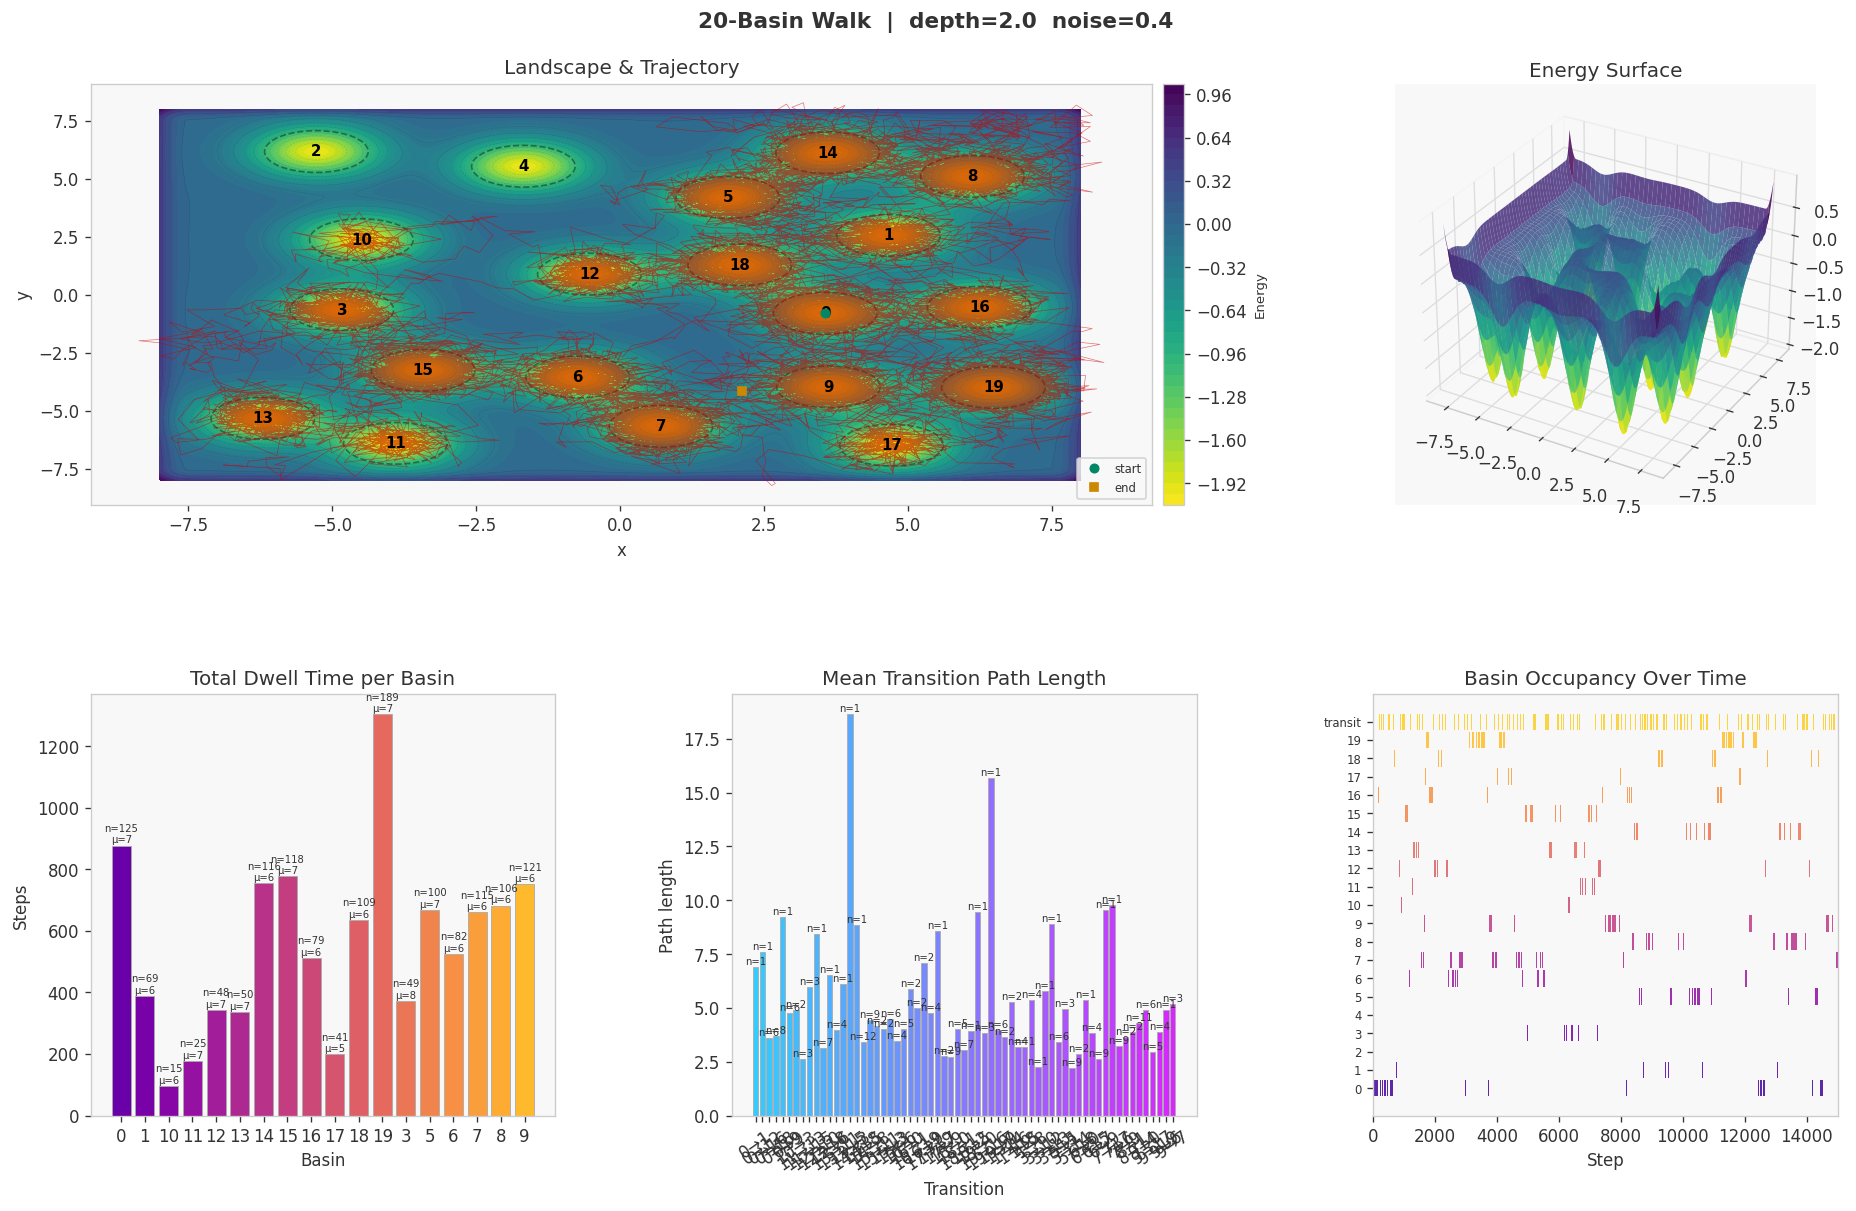

In [9]:
# ── Configure your walk here ──────────────────────────────────────────────────
cfg = make_20_basin_config(
    depth        = 2.0,   # well depth
    width        = 0.8,   # Gaussian σ (catchment size)
    noise_sigma  = 0.40,  # thermal noise amplitude
    force_scale  = 0.20,  # Langevin dt/γ  — raise to make depth matter more
    n_steps      = 15_000,
    seed         = 42,
)

print(f"Running {cfg.n_steps:,} steps over {len(cfg.basins)} basins  "
      f"(noise={cfg.noise_sigma}, force_scale={cfg.force_scale}, depth={cfg.basins[0].depth})")

traj, basin_seq, dwell_recs, trans_recs = run_walk(cfg)
summarise(cfg, dwell_recs, trans_recs)
plot_results(cfg, traj, basin_seq, dwell_recs, trans_recs,
             title=f"20-Basin Walk  |  depth={cfg.basins[0].depth}  noise={cfg.noise_sigma}")


## 7 · Psychosis Presets

Three 3-basin configurations modelling qualitatively different attractor landscapes.



  HEALTHY
  DWELL TIME SUMMARY
             n_visits   total    mean     std   min     max
basin_label                                                
A                  13  7988.0  614.46  464.31  36.0  1319.0

  TRANSITION PATH LENGTHS
  No transitions recorded.


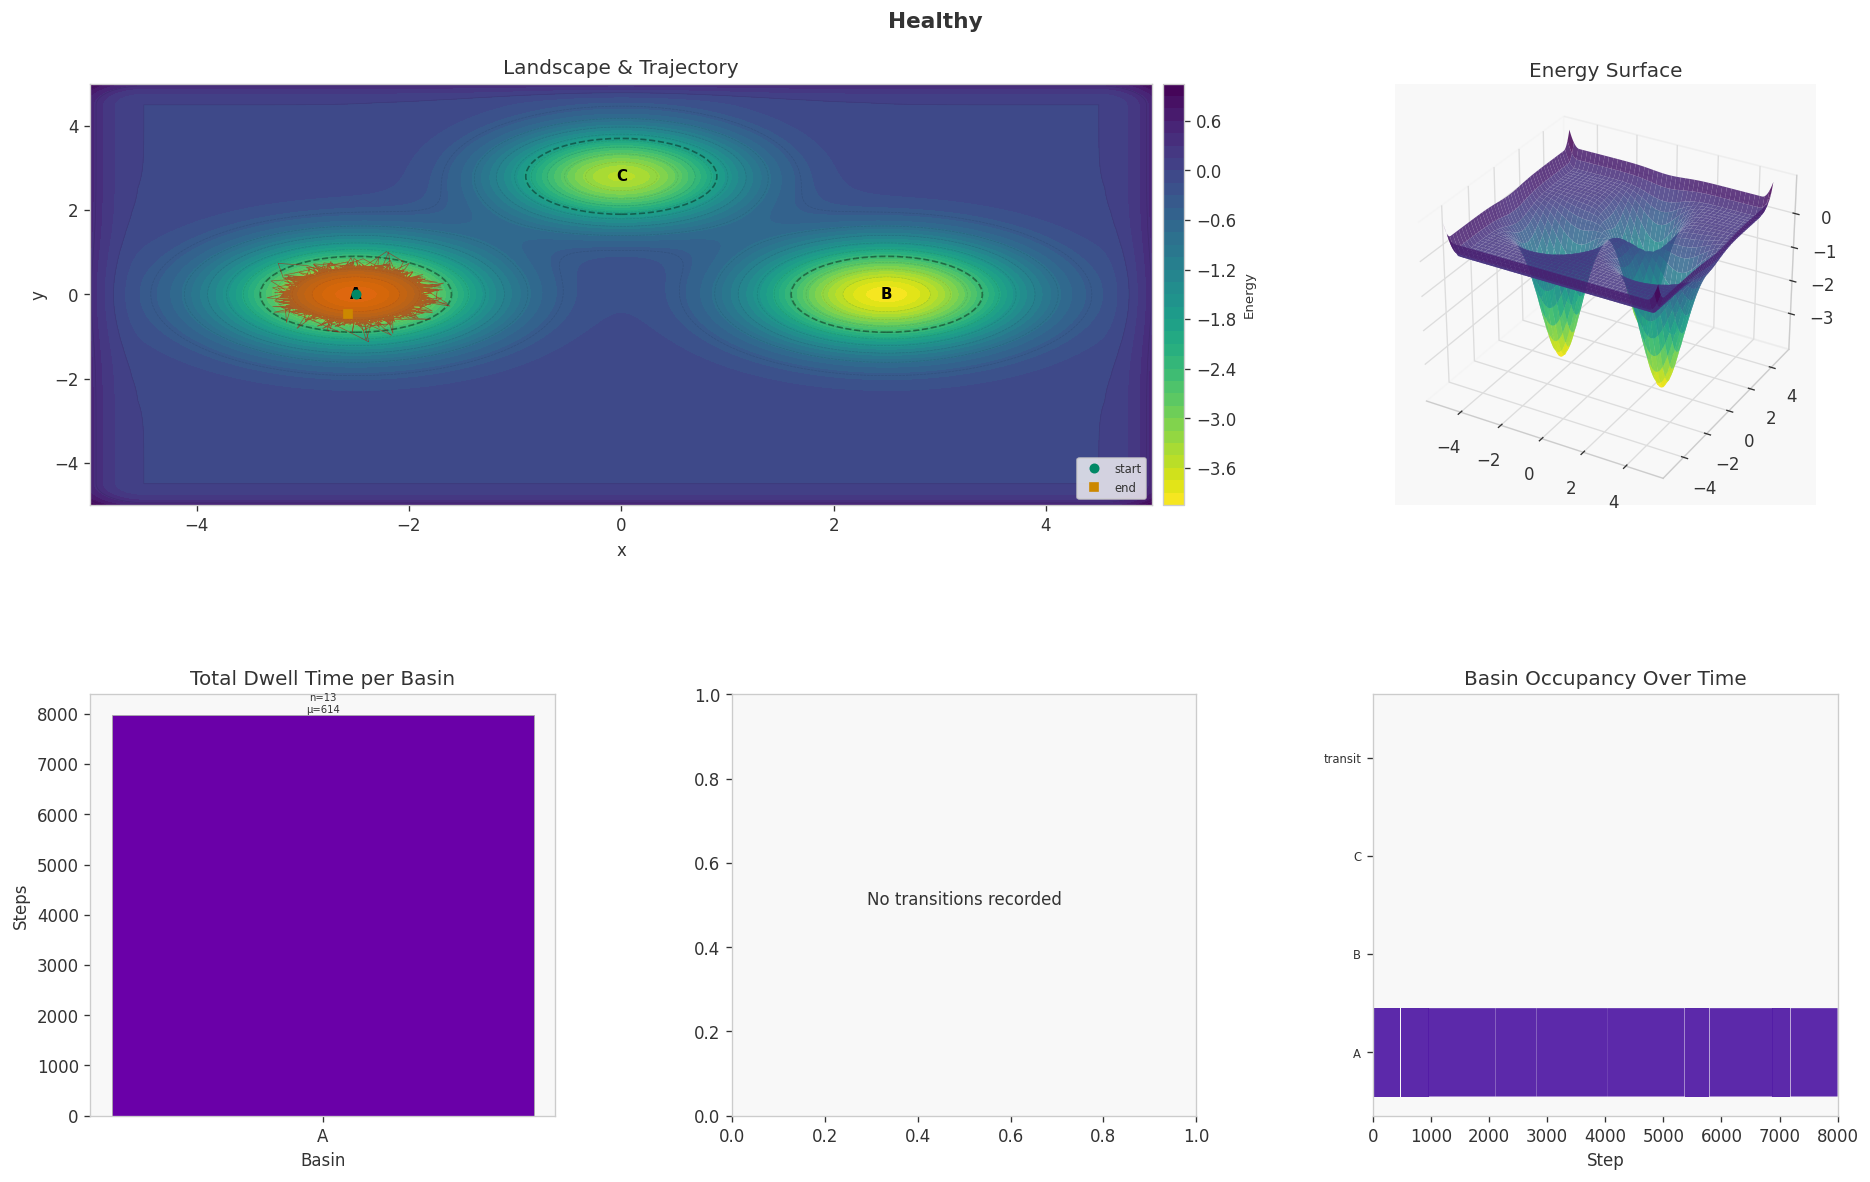


  ACUTE PSYCHOSIS
  DWELL TIME SUMMARY
             n_visits  total  mean   std  min   max
basin_label                                        
A                 222  544.0  2.45  1.84  1.0   9.0
B                 130  302.0  2.32  1.89  1.0  13.0
C                 141  308.0  2.18  1.64  1.0  10.0

  TRANSITION PATH LENGTHS
                      n    mean     std    min      max
from_label to_label                                    
A          B         19  35.499  40.090  4.613  154.782
           C         24  14.056  22.320  1.316   78.096
B          A         19  17.137  19.469  3.530   64.229
           C         21  11.722  13.643  2.118   49.757
C          A         24  12.825  15.847  1.847   57.941
           B         21  15.725  25.341  2.010  108.468


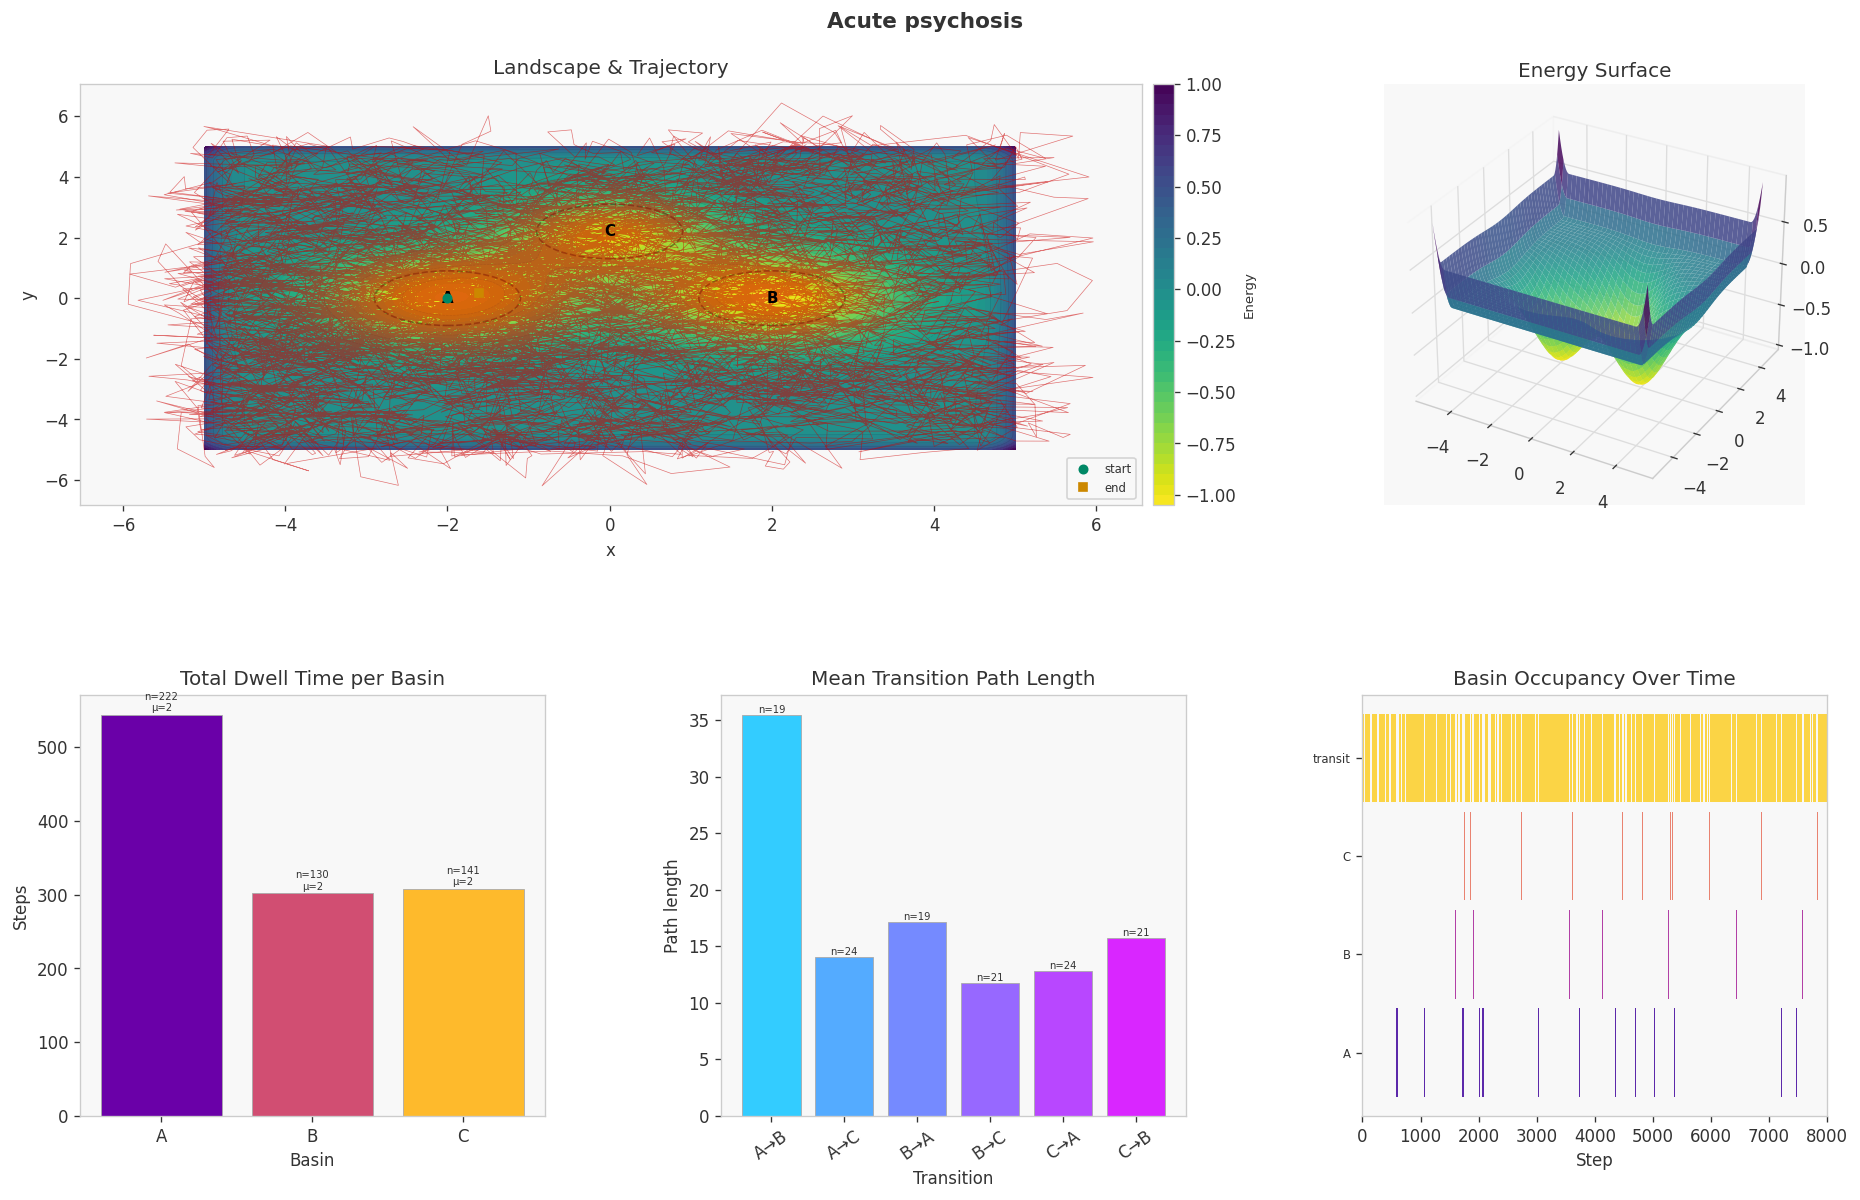


  PERSEVERATIVE PSYCHOSIS
  DWELL TIME SUMMARY
             n_visits   total  mean   std  min   max
basin_label                                         
A_norm             16   134.0  8.38  7.22  1.0  22.0
P_path            771  6926.0  8.98  8.39  1.0  57.0

  TRANSITION PATH LENGTHS
                     n   mean  std    min    max
from_label to_label                             
A_norm     P_path    1  3.735  NaN  3.735  3.735


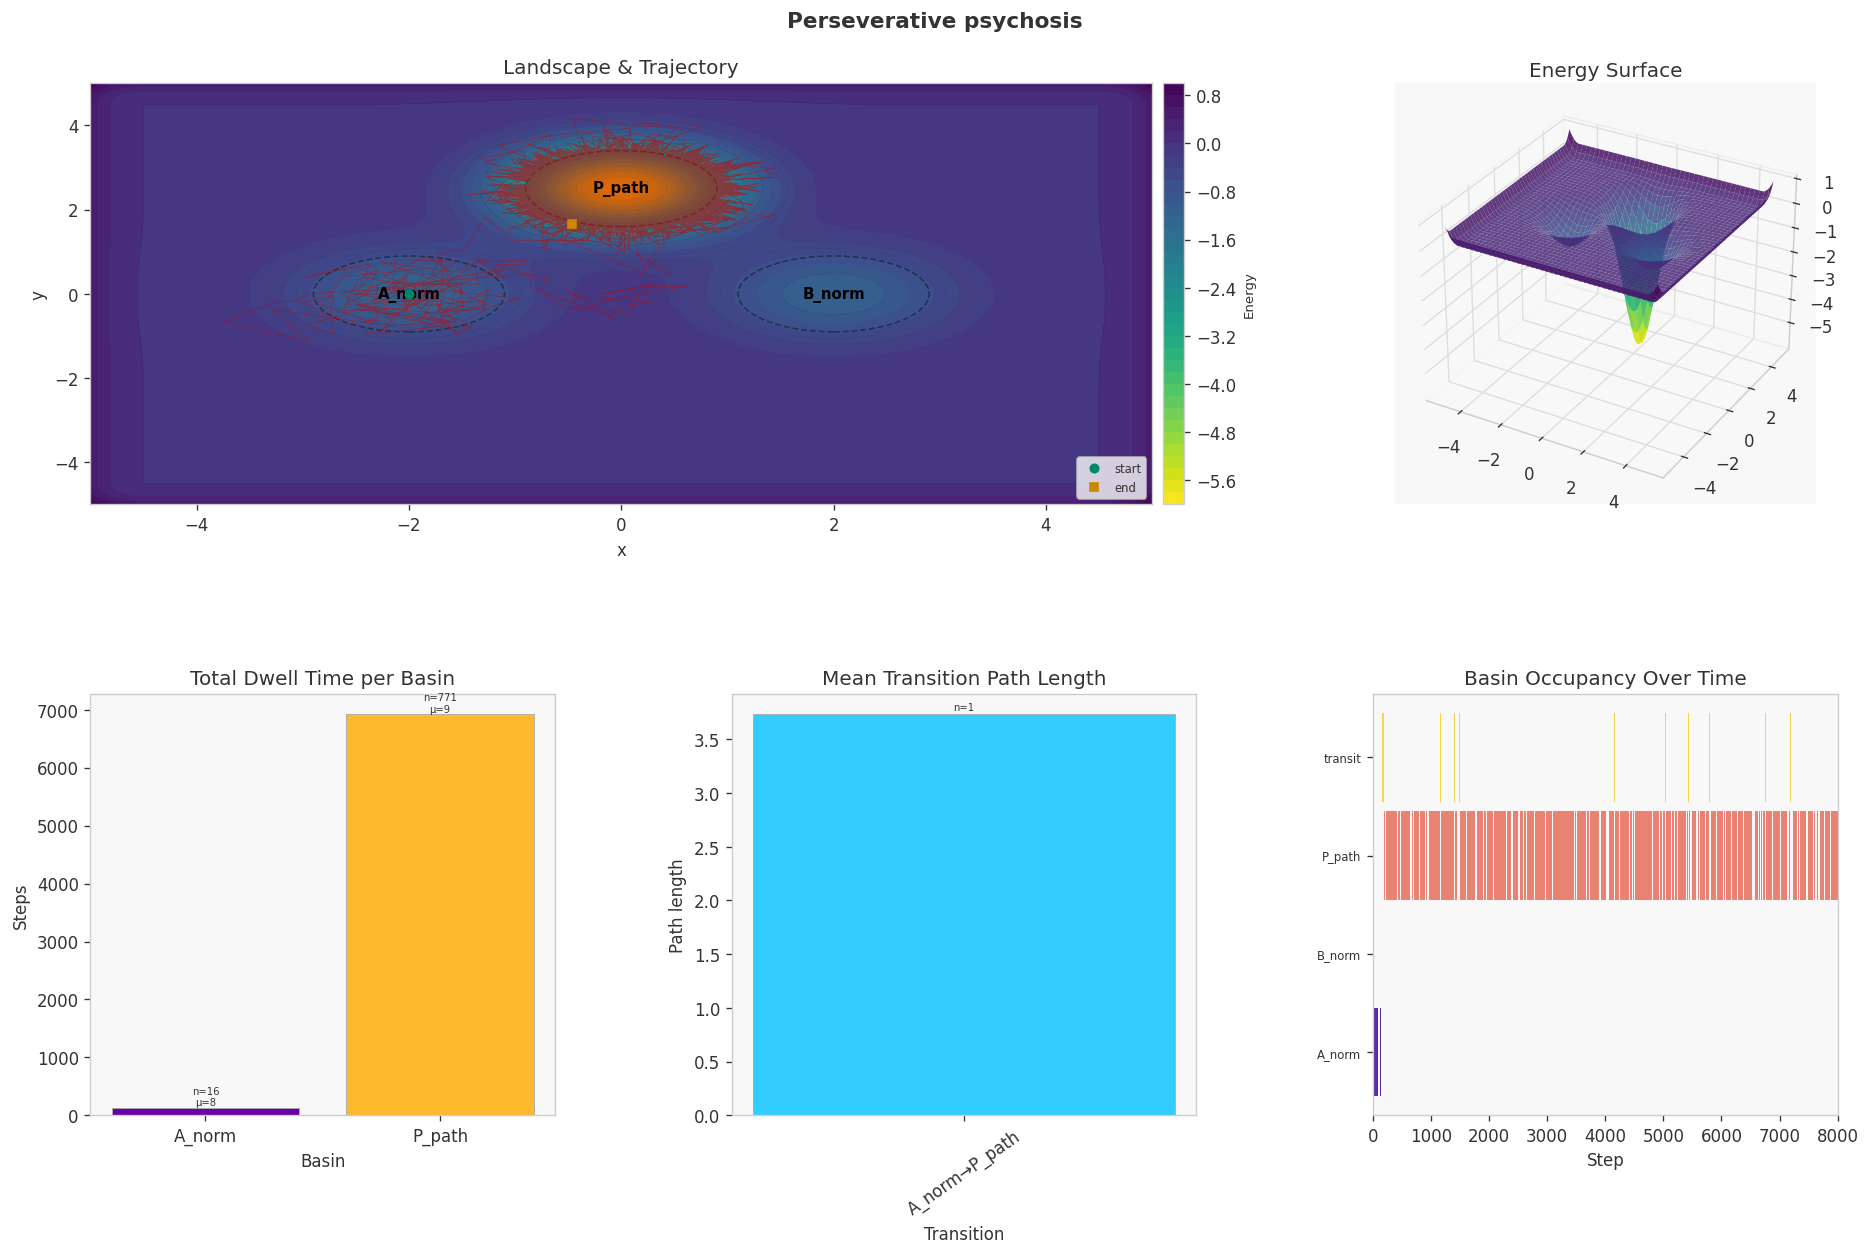

In [9]:
PRESETS = {
    "Healthy": LandscapeConfig(
        basins=[Basin(-2.5, 0.0, depth=4.0, width=0.9, label="A"),
                Basin( 2.5, 0.0, depth=4.0, width=0.9, label="B"),
                Basin( 0.0, 2.8, depth=3.5, width=0.8, label="C")],
        noise_sigma=0.25, force_scale=0.20, n_steps=8000,
        x_range=(-5,5), y_range=(-5,5),
    ),
    "Acute psychosis": LandscapeConfig(
        basins=[Basin(-2.0, 0.0, depth=1.0, width=1.2, label="A"),
                Basin( 2.0, 0.0, depth=1.0, width=1.2, label="B"),
                Basin( 0.0, 2.2, depth=0.8, width=1.0, label="C")],
        noise_sigma=0.55, force_scale=0.20, n_steps=8000,
        x_range=(-5,5), y_range=(-5,5),
    ),
    "Perseverative psychosis": LandscapeConfig(
        basins=[Basin(-2.0, 0.0, depth=1.2, width=0.8, label="A_norm"),
                Basin( 2.0, 0.0, depth=1.2, width=0.8, label="B_norm"),
                Basin( 0.0, 2.5, depth=6.0, width=0.7, label="P_path")],
        noise_sigma=0.35, force_scale=0.20, n_steps=8000,
        x_range=(-5,5), y_range=(-5,5),
    ),
}

for name, cfg in PRESETS.items():
    print(f"\n{'='*60}\n  {name.upper()}\n{'='*60}")
    traj, basin_seq, dwell_recs, trans_recs = run_walk(cfg)
    summarise(cfg, dwell_recs, trans_recs)
    plot_results(cfg, traj, basin_seq, dwell_recs, trans_recs, title=name)


In [34]:
DEPTHS_SW2 = [0.25,0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0]
NOISES_SW2 = [0.20, 0.30, 0.40, 0.5, 0.75, 1.00]
WIDTH_SW2  = 0.8
N_STEPS_SW2 = 10000
N_REPS_SW2  = 5
FORCE_SCALE = 0.20

print(f"Sweep 2: {len(DEPTHS_SW2)} depths × {len(NOISES_SW2)} noises × {N_REPS_SW2} reps "
      f"= {len(DEPTHS_SW2)*len(NOISES_SW2)*N_REPS_SW2} runs  |  width={WIDTH_SW2} fixed")

records2 = []
total2   = len(DEPTHS_SW2) * len(NOISES_SW2) * N_REPS_SW2
done2    = 0

for depth in DEPTHS_SW2:
    for noise in NOISES_SW2:
        for rep in range(N_REPS_SW2):
            cfg = make_20_basin_config(
                depth=depth, width=WIDTH_SW2, noise_sigma=noise,
                force_scale=FORCE_SCALE, n_steps=N_STEPS_SW2,
                basin_radius=0.9, min_separation=2.5,
                x_range=(-8,8), y_range=(-8,8),
                seed=rep,
            )
            _, basin_seq, dwell_recs, trans_recs = run_walk(cfg)

            if dwell_recs:
                df_d = pd.DataFrame(dwell_recs)
                mean_dwell = df_d["duration_time"].mean()
                frac_in    = df_d["duration_time"].sum() / N_STEPS_SW2
                cv_dwell   = df_d["duration_time"].std() / (mean_dwell + 1e-9)
            else:
                mean_dwell = frac_in = cv_dwell = float("nan")

            if trans_recs:
                df_t = pd.DataFrame(trans_recs)
                mean_path = df_t["path_length"].mean()
                n_trans   = len(df_t)
            else:
                mean_path = float("nan"); n_trans = 0

            visited = len(set(b for b in basin_seq if b is not None))
            records2.append(dict(depth=depth, noise=noise, rep=rep,
                                 mean_dwell=mean_dwell, mean_path=mean_path,
                                 frac_in_basin=frac_in, n_transitions=n_trans,
                                 basins_visited=visited, cv_dwell=cv_dwell))
            done2 += 1
            if done2 % (total2 // 10) == 0 or done2 == total2:
                print(f"  {done2}/{total2} runs complete ({100*done2/total2:.0f}%)")

df_sw2 = pd.DataFrame(records2)
# Replace 0 with NaN for metrics where 0 means "no data"
for c in ["n_transitions", "basins_visited"]:
    df_sw2[c] = df_sw2[c].replace(0, np.nan)
agg2   = df_sw2.groupby(["depth","noise"]).mean(numeric_only=True).reset_index()
print("\nSweep 2 complete.")
agg2[["depth","noise","mean_dwell","mean_path","frac_in_basin","n_transitions","basins_visited"]].round(2)

Sweep 2: 8 depths × 6 noises × 5 reps = 240 runs  |  width=0.8 fixed
  24/240 runs complete (10%)
  24/240 runs complete (10%)
  48/240 runs complete (20%)
  48/240 runs complete (20%)
  72/240 runs complete (30%)
  72/240 runs complete (30%)
  96/240 runs complete (40%)
  96/240 runs complete (40%)
  120/240 runs complete (50%)
  120/240 runs complete (50%)
  144/240 runs complete (60%)
  144/240 runs complete (60%)
  168/240 runs complete (70%)
  168/240 runs complete (70%)
  192/240 runs complete (80%)
  192/240 runs complete (80%)
  216/240 runs complete (90%)
  216/240 runs complete (90%)
  240/240 runs complete (100%)

Sweep 2 complete.
  240/240 runs complete (100%)

Sweep 2 complete.


,depth,noise,mean_dwell,mean_path,frac_in_basin,n_transitions,basins_visited
0,0.25,0.20,9.54,7.56,0.50,63.60,17.0
1,0.25,0.30,4.55,9.04,0.31,153.20,20.0
2,0.25,0.40,3.25,9.22,0.26,241.40,20.0
3,0.25,0.50,2.47,8.95,0.23,339.80,20.0
4,0.25,0.75,1.72,9.42,0.20,587.60,20.0
5,0.25,1.00,1.41,10.85,0.19,788.00,20.0
6,0.50,0.20,16.61,4.55,0.75,45.00,12.6
7,0.50,0.30,5.81,7.11,0.45,144.00,19.4
8,0.50,0.40,3.53,8.03,0.31,239.20,20.0
9,0.50,0.50,2.60,8.33,0.26,344.20,20.0


In [35]:
agg2.to_csv("sweep2_results.csv", index=False)

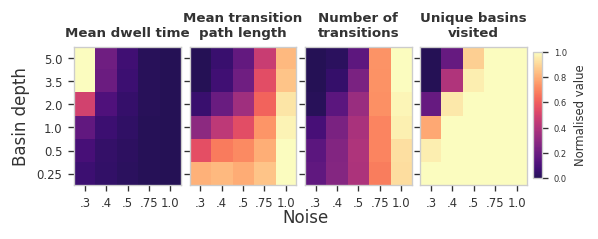

In [36]:
def plot_heatmaps(agg, row_var, col_var, row_vals, col_vals,
                  metrics, title, figsize=(5, 1.5)):
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharey=True)
    axes = axes.flatten() #if n_metrics > 1 else [axes]
    if n_metrics == 1:
        axes = [axes]

    # Filter to noise >= 0.3
    agg_filt = agg[agg[col_var] >= 0.3].copy()
    col_vals_filt = [v for v in col_vals if v >= 0.3]

    # Filter rows to depth <= 5
    agg_filt = agg_filt[agg_filt[row_var] <= 5].copy()
    row_vals_filt = [v for v in row_vals if v <= 5]

    # Truncated magma: avoid very dark end
    from matplotlib.colors import LinearSegmentedColormap
    magma_full = plt.cm.magma
    magma_trunc = LinearSegmentedColormap.from_list(
        "magma_trunc", magma_full(np.linspace(0.15, 1, 256)))

    # Build raw matrices and min-max normalised matrices (per metric)
    # vmin/vmax set to 5th/95th percentile per matrix
    norm_mats = []
    raw_mats = []
    for col, label, cmap in metrics:
        mat = agg_filt.pivot(index=row_var, columns=col_var, values=col)
        raw_mats.append(mat)
        vals = mat.values.copy().astype(float)
        valid_vals = vals[~np.isnan(vals)]
        p5, p95 = np.percentile(valid_vals, 5), np.percentile(valid_vals, 95)
        if p95 - p5 > 0:
            normed = (vals - p5) / (p95 - p5)
        else:
            normed = np.zeros_like(vals)
        normed = np.clip(normed, 0, 1)
        normed[np.isnan(vals)] = np.nan
        norm_mats.append(normed)

    for idx, (ax, (col, label, cmap), norm_mat, raw_mat) in enumerate(
            zip(axes, metrics, norm_mats, raw_mats)):
        im = ax.imshow(norm_mat, aspect="auto", origin="lower",
                       cmap=magma_trunc, interpolation="nearest",
                       vmin=0, vmax=1)
        ax.set_xticks(range(len(col_vals_filt)))
        ax.set_xticklabels([str(v).lstrip('0') for v in col_vals_filt], fontsize=7)
        ax.set_yticks(range(len(row_vals_filt)))
        ax.set_yticklabels([str(v) for v in row_vals_filt], fontsize=7)
        ax.set_title(label, fontsize=8, fontweight="bold")

        # +/- sign annotations
        for i in range(norm_mat.shape[0]):
            for j in range(norm_mat.shape[1]):
                rv = raw_mat.values[i, j]
                if not np.isnan(rv):
                    sign = "" if rv >= 0 else "−"
                    ax.text(j, i, sign, ha="center", va="center",
                            fontsize=8, fontweight="bold", color="black")

        # Shared axis labels — only on edges
        if idx == 0:
            ax.set_ylabel('Basin depth', fontsize=10)
        ax.set_xlabel("")

    # Single shared x-label
    fig.text(0.51, -0.1, 'Noise', ha="center", fontsize=10)

    # Single shared colourbar (0–1 range) — manually positioned
    plt.subplots_adjust(wspace=0.08, right=0.88)
    cax = fig.add_axes([0.89, 0.15, 0.015, 0.7])   # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Normalised value", fontsize=7)
    cbar.ax.tick_params(labelsize=5)

   # fig.suptitle(title, fontsize=10, fontweight="bold", y=1.02)

METRICS = [
    ("mean_dwell",    "Mean dwell time",     "magma"),
    ("mean_path",     "Mean transition\npath length", "magma"),
    ("n_transitions", "Number of\ntransitions",               "magma"),
    ("basins_visited","Unique basins\nvisited",        "magma")]

plot_heatmaps(agg2, "depth", "noise", DEPTHS_SW2, NOISES_SW2,
              METRICS, f"Noise × Depth Sweep  |  width={WIDTH_SW2}, force_scale={FORCE_SCALE}")
plt.savefig('/home/ll16598/Documents/POSTDOC/SCHIZ/plots/heatmaps.png', dpi=800, bbox_inches='tight')
plt.show()


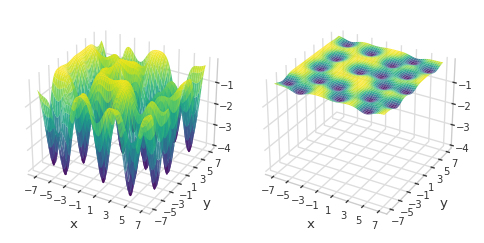

In [33]:
# 3D energy landscapes: deep vs shallow basins
cfg_deep = make_20_basin_config(depth=4.0, width=0.8, noise_sigma=0.4,
                                 force_scale=0.20, n_steps=100, seed=42)
cfg_shallow = make_20_basin_config(depth=0.25, width=0.8, noise_sigma=0.4,
                                    force_scale=0.20, n_steps=100, seed=42)

fig = plt.figure(figsize=(5, 3))
axes_3d = []
zz_list = []
for k, (cfg_plot, label) in enumerate([(cfg_deep, "Deep basins (depth = 4)"),
                                        (cfg_shallow, "Shallow basins (depth = 0.25)")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    res = 160
    # Inset grid by 1.0 to avoid rendering the soft-wall region
    margin = 1.0
    xs = np.linspace(cfg_plot.x_range[0] + margin, cfg_plot.x_range[1] - margin, res)
    ys = np.linspace(cfg_plot.y_range[0] + margin, cfg_plot.y_range[1] - margin, res)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.vectorize(lambda x, y: energy(cfg_plot, x, y))(XX, YY)
    zz_list.append(ZZ)
    ax.plot_surface(XX, YY, ZZ, cmap="viridis", alpha=0.9,
                    linewidth=0, antialiased=True, rcount=60, ccount=60)
   # ax.set_title(label, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel("x", fontsize=8, labelpad=-8)
    ax.set_ylabel("y", fontsize=8, labelpad=-8)
    ax.set_zlabel("Energy", fontsize=8, labelpad=-6)
    # Integer ticks on x and y
    x_lo_int = int(np.ceil(xs.min()))
    x_hi_int = int(np.floor(xs.max()))
    y_lo_int = int(np.ceil(ys.min()))
    y_hi_int = int(np.floor(ys.max()))
    ax.set_xticks(np.arange(x_lo_int, x_hi_int+1, 2))
    ax.set_yticks(np.arange(y_lo_int, y_hi_int+1, 2))
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("w")
    ax.yaxis.pane.set_edgecolor("w")
    ax.zaxis.pane.set_edgecolor("w")
    ax.set_facecolor("white")
    ax.tick_params(labelsize=6, pad=-4)
    # if k == 0:
    #     ax.set_zticklabels([])
    axes_3d.append(ax)

# Shared z-axis limits so depth difference is visually clear
z_lo = min(zz.min() for zz in zz_list)
z_hi = max(zz.max() for zz in zz_list)
for ax in axes_3d:
    ax.set_zlim(z_lo, z_hi)
plt.subplots_adjust(wspace=0.1, right=0.88)

plt.savefig('/home/ll16598/Documents/POSTDOC/SCHIZ/plots/landscape.png', dpi=800, bbox_inches='tight')
plt.show()

---
## 8 · Parameter Sweep: Depth × Width

Systematically vary `depth` and `width` at fixed noise.  
Records all response variables at each combination (3 seeds per cell).


In [ ]:
DEPTHS_SWEEP1 = [0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
WIDTHS_SWEEP1 = [0.4, 0.6, 0.8, 1.1, 1.5, 2.0]
NOISE_SWEEP1  = 0.4
N_STEPS_SW1   = 12_000
N_REPS_SW1    = 3

print(f"Sweep 1: {len(DEPTHS_SWEEP1)} depths × {len(WIDTHS_SWEEP1)} widths × {N_REPS_SW1} reps "
      f"= {len(DEPTHS_SWEEP1)*len(WIDTHS_SWEEP1)*N_REPS_SW1} runs")

records1 = []
total1   = len(DEPTHS_SWEEP1) * len(WIDTHS_SWEEP1) * N_REPS_SW1
done1    = 0

for depth in DEPTHS_SWEEP1:
    for width in WIDTHS_SWEEP1:
        basin_radius = width * 1.1
        span = max(16.0, width * 22); half = span / 2

        for rep in range(N_REPS_SW1):
            cfg = make_20_basin_config(
                depth=depth, width=width, noise_sigma=NOISE_SWEEP1,
                force_scale=0.20, n_steps=N_STEPS_SW1,
                basin_radius=basin_radius,
                min_separation=max(2.0, width*2.5),
                x_range=(-half, half), y_range=(-half, half),
                seed=42+rep*100,
            )
            _, basin_seq, dwell_recs, trans_recs = run_walk(cfg)

            if dwell_recs:
                df_d = pd.DataFrame(dwell_recs)
                mean_dwell   = df_d["duration_time"].mean()
                frac_in      = df_d["duration_time"].sum() / N_STEPS_SW1
                cv_dwell     = df_d["duration_time"].std() / (mean_dwell + 1e-9)
                total_visits = len(df_d)
            else:
                mean_dwell = frac_in = cv_dwell = float("nan"); total_visits = 0

            if trans_recs:
                df_t = pd.DataFrame(trans_recs)
                mean_path = df_t["path_length"].mean()
                n_trans   = len(df_t)
            else:
                mean_path = float("nan"); n_trans = 0

            visited = len(set(b for b in basin_seq if b is not None))
            records1.append(dict(depth=depth, width=width, rep=rep,
                                 mean_dwell=mean_dwell, mean_path=mean_path,
                                 frac_in_basin=frac_in, n_transitions=n_trans,
                                 basins_visited=visited, cv_dwell=cv_dwell))
            done1 += 1
            if done1 % 18 == 0 or done1 == total1:
                print(f"  {done1}/{total1} runs complete")

df_sw1 = pd.DataFrame(records1)
agg1   = df_sw1.groupby(["depth","width"]).mean(numeric_only=True).reset_index()
print("\nSweep 1 complete.")
agg1[["depth","width","mean_dwell","mean_path","frac_in_basin","n_transitions","basins_visited"]].round(2)


In [10]:


plot_heatmaps(agg1, "depth", "width", DEPTHS_SWEEP1, WIDTHS_SWEEP1,
              METRICS, f"Depth × Width Sweep  |  noise={NOISE_SWEEP1}, 20 basins")


NameError: name 'agg1' is not defined

In [ ]:
# Marginal line plots — effect of depth, lines = width
palette_w = plt.cm.viridis(np.linspace(0.15, 0.9, len(WIDTHS_SWEEP1)))
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Effect of Depth on Response Variables  (lines = Width σ)",
             fontsize=12, fontweight="bold", y=0.99)
for ax, (ycol, ylabel, _) in zip(axes.flat, METRICS):
    for j, w in enumerate(WIDTHS_SWEEP1):
        sub = agg1[agg1.width == w].sort_values("depth")
        ax.plot(sub["depth"], sub[ycol], "-o", color=palette_w[j],
                lw=1.6, ms=4, label=f"w={w}", alpha=0.9)
    ax.set_xlabel("Depth"); ax.set_ylabel(ylabel); ax.set_title(ylabel, fontsize=9)
axes.flat[0].legend(fontsize=6.5, ncol=2, title="Width")
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()


---
## 9 · Parameter Sweep: Noise × Depth  *(fixed width = 0.8)*

Width fixed at 0.8. The key question: does the Langevin model make depth meaningful across noise levels?


In [ ]:
# Lines: effect of noise, coloured by depth
palette_d = plt.cm.plasma(np.linspace(0.1, 0.9, len(DEPTHS_SW2)))
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Effect of Noise on Response Variables  (lines = Depth)",
             fontsize=12, fontweight="bold", y=0.99)
for ax, (ycol, ylabel, _) in zip(axes.flat, METRICS):
    for i, d in enumerate(DEPTHS_SW2):
        sub = agg2[agg2.depth == d].sort_values("noise")
        ax.plot(sub["noise"], sub[ycol], "-o", color=palette_d[i],
                lw=1.6, ms=4, label=f"d={d}", alpha=0.9)
    ax.set_xlabel("Noise σ"); ax.set_ylabel(ylabel); ax.set_title(ylabel, fontsize=9)
axes.flat[0].legend(fontsize=6.5, ncol=2, title="Depth")
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()


In [ ]:
# 3D response surfaces
from mpl_toolkits.mplot3d import Axes3D  # noqa
D_arr = np.array(DEPTHS_SW2)
N_arr = np.array(NOISES_SW2)
NN, DD = np.meshgrid(N_arr, D_arr)

surface_vars = [
    ("mean_dwell",    "Mean Dwell Time",       "plasma"),
    ("mean_path",     "Mean Transition Path",  "viridis"),
    ("basins_visited","Unique Basins Visited", "cool"),
]

fig = plt.figure(figsize=(17, 5))
fig.suptitle(f"3D Response Surfaces  |  width={WIDTH_SW2}, force_scale={FORCE_SCALE}",
             fontsize=12, fontweight="bold")
for k, (col, label, cmap) in enumerate(surface_vars):
    ax = fig.add_subplot(1, 3, k+1, projection="3d")
    mat = agg2.pivot(index="depth", columns="noise", values=col).values
    ax.plot_surface(DD, NN, mat, cmap=cmap, alpha=0.88,
                    linewidth=0, antialiased=True, rcount=50, ccount=50)
    ax.set_xlabel("Depth", fontsize=8, labelpad=4)
    ax.set_ylabel("Noise σ", fontsize=8, labelpad=4)
    ax.set_zlabel(label, fontsize=7, labelpad=4)
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
plt.tight_layout(); plt.show()


## 10 · Save Results to CSV

In [ ]:
# Save aggregated sweep results
agg1.to_csv("sweep1_depth_x_width.csv", index=False)
agg2.to_csv("sweep2_noise_x_depth.csv", index=False)
df_sw1.to_csv("sweep1_raw.csv", index=False)
df_sw2.to_csv("sweep2_raw.csv", index=False)
print("Saved: sweep1_depth_x_width.csv, sweep2_noise_x_depth.csv")
print("       sweep1_raw.csv, sweep2_raw.csv")
